# Week #3 Histogram and Spatial Filtering

In [2]:
!wget "https://drive.google.com/uc?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe" -O kitty.jpg
!wget "https://drive.google.com/uc?id=1Z5tdeugKi8LyB2g-jJTwu3Y89Ljqj_SF" -O area.jpg
!wget "https://drive.google.com/uc?id=1Ku89NM5rj6O3POXLT8vlhh6xDv5AHqXG" -O camaraman.tif
!wget "https://drive.google.com/uc?id=1J_SEj79YhWVcQrQKVEQkBDHroB-LxZgQ" -O moon.png
!wget "https://drive.google.com/uc?id=1eCyTF6u_w6bIDWrPONXJO5K0mo16DWwV" -O sudoku.jpg
!wget "https://drive.google.com/uc?id=1QNPXTo3IzGX39c_zhS4wUY79c-6-V3TI" -O space.png

--2025-09-18 23:30:46--  https://drive.google.com/uc?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe
Resolving drive.google.com (drive.google.com)... 2404:6800:4001:80d::200e, 172.217.26.206
Connecting to drive.google.com (drive.google.com)|2404:6800:4001:80d::200e|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe [following]
--2025-09-18 23:30:47--  https://drive.usercontent.google.com/download?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 2404:6800:4001:811::2001, 142.251.223.33
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|2404:6800:4001:811::2001|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 79570 (78K) [image/jpeg]
Saving to: ‘kitty.jpg’

kitty.jpg           100%[===================>]  77.71K   283KB/s    in 0.3s    

2025-09-18 23:30:49 (283 KB/s) - ‘kitty.jp

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Exercise #1 Histogram
* grayscale
* rgb
* equalization
* CLAHE

* Grayscale Histogram

---

calHist - https://docs.opencv.org/3.4/d6/dc7/group__imgproc__hist.html#ga4b2b5fd75503ff9e6844cc4dcdaed35d

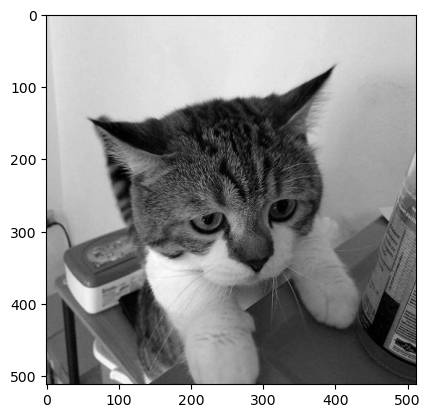

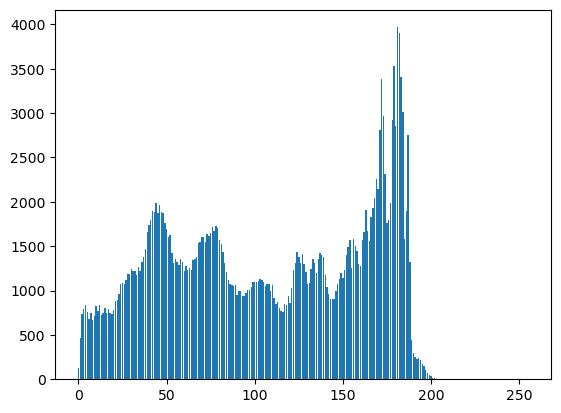

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread("kitty.jpg")
img_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])
plt.imshow(img_gray,cmap='gray');plt.show()
plt.bar(range(0,256),hist[:,0])
plt.show()

* RGB Histogram

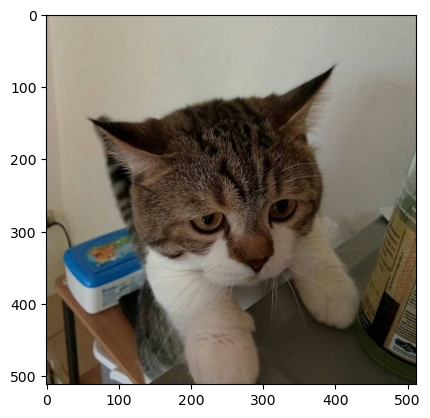

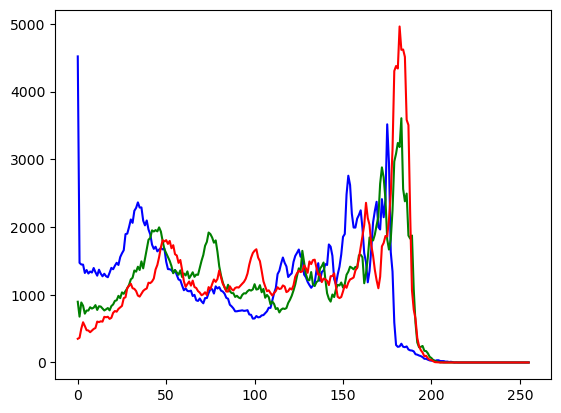

In [5]:
plt.imshow(img[:,:,::-1]);plt.show()
chans = cv2.split(img)
colors = ("b", "g", "r")
for (chan, color) in zip(chans, colors):
  # create a histogram for the current channel and plot it
  hist = cv2.calcHist([chan], [0], None, [256], [0, 256])
  plt.plot(range(0,256),hist[:,0],color=color)

plt.show()

* Histogram Equalization

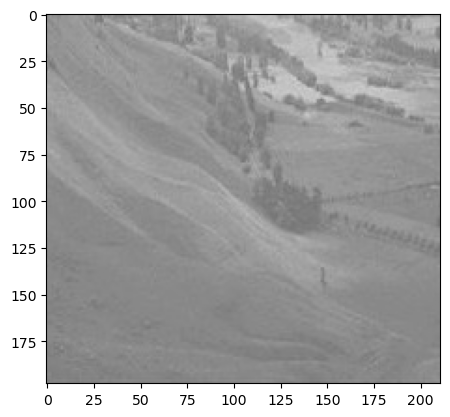

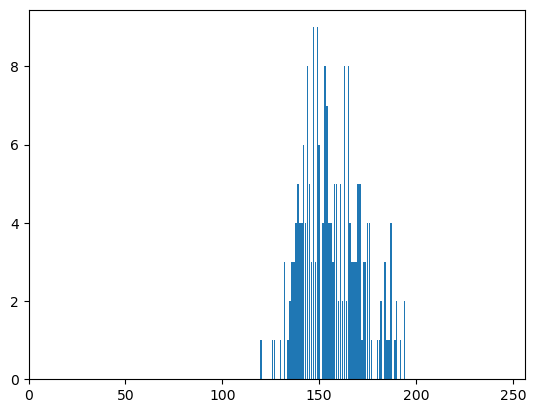

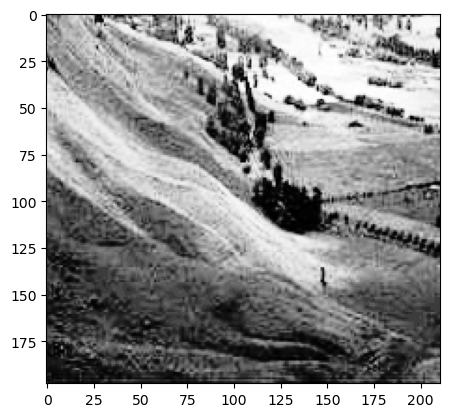

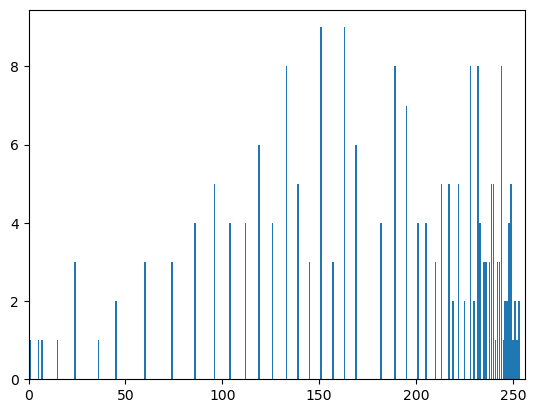

In [6]:
import cv2
img = cv2.imread("area.jpg")
img_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

# plot histogram of equalization + plot the histogram before and after equalized
# img_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
hist = cv2.calcHist(img_gray, [0], None, [256], [0, 256])
plt.imshow(img_gray,cmap='gray',vmin=0,vmax=255);plt.show()
plt.bar(range(0,256),hist[:,0])
plt.xlim([0, 256])
plt.show()

equ = cv2.equalizeHist(img_gray)
plt.imshow(equ,cmap='gray')
plt.show()

histeq = cv2.calcHist(equ, [0], None, [256], [0, 256])
plt.bar(range(0,256),histeq[:,0])
plt.xlim([0, 256])
plt.show()

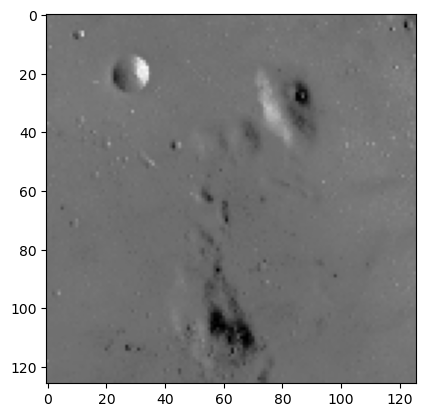

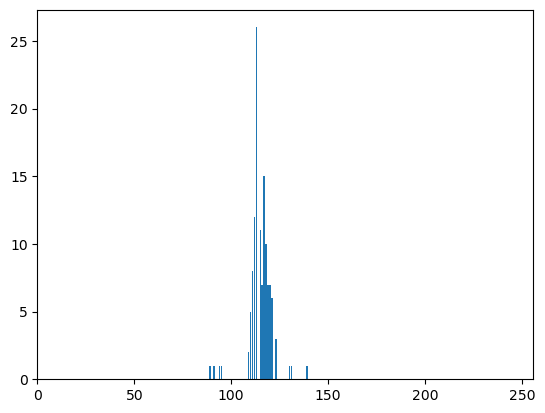

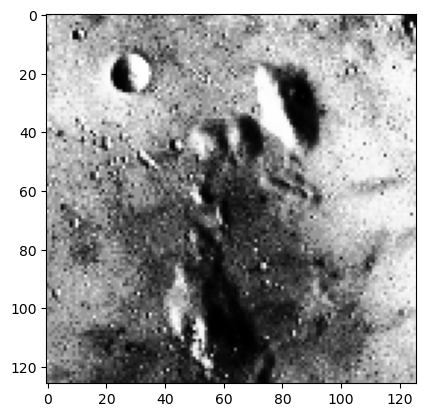

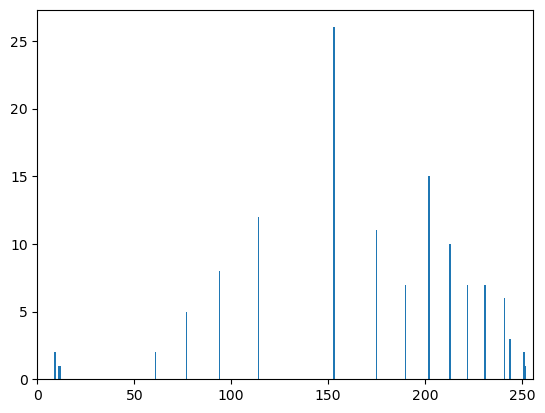

In [7]:
import cv2
img = cv2.imread("space.png")
img_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

# plot histogram of equalization + plot the histogram before and after equalized
# img_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
hist = cv2.calcHist(img_gray, [0], None, [256], [0, 256])
plt.imshow(img_gray,cmap='gray',vmin=0,vmax=255);plt.show()
plt.bar(range(0,256),hist[:,0])
plt.xlim([0, 256])
plt.show()

equ = cv2.equalizeHist(img_gray)
plt.imshow(equ,cmap='gray')
plt.show()

histeq = cv2.calcHist(equ, [0], None, [256], [0, 256])
plt.bar(range(0,256),histeq[:,0])
plt.xlim([0, 256])
plt.show()


* CLAHE

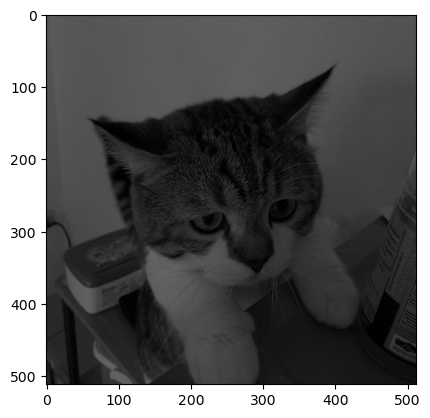

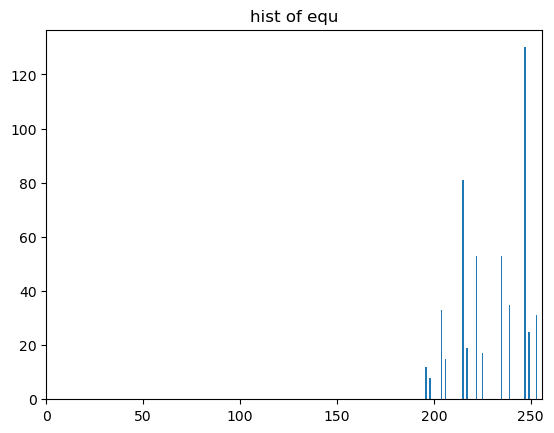

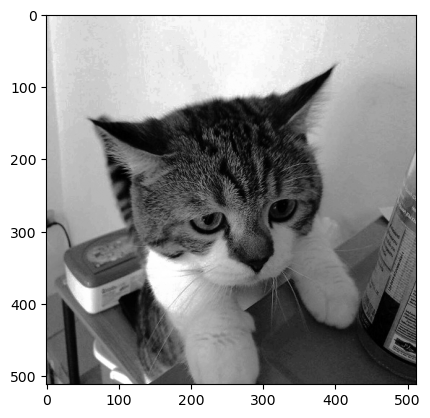

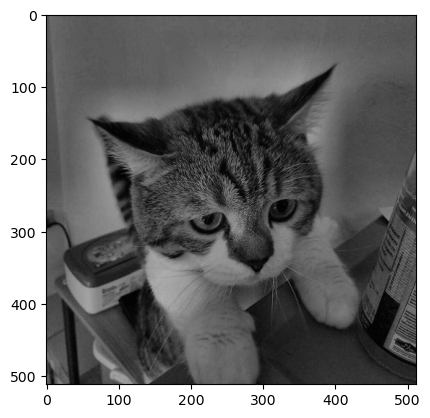

In [8]:
GAIN = 2

# Generate low contrast image
img = cv2.imread("kitty.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = cv2.divide(img,GAIN)

# Write your code to visualize the results
plt.imshow(img,cmap='gray',vmin=0,vmax=255)
plt.show()

# Use Histogram Equalization
equ = cv2.equalizeHist(img)
histeq = cv2.calcHist(equ, [0], None, [256], [0, 256])
plt.bar(range(0,256),histeq[:,0])
plt.title('hist of equ')
plt.xlim([0, 256])
plt.show()
plt.imshow(equ,cmap='gray',vmin=0,vmax=255)
plt.show()



# Use CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl1 = clahe.apply(img)
plt.imshow(cl1,cmap='gray',vmin=0,vmax=255)
plt.show()

# TO DO : Use CLAHE - change cliplimit to 2.0 and grid size to 1x1


## Exercise #2 Spatial Filtering
*  Filter2D

In [9]:
small_im = np.random.random((5,5))*100
small_im = small_im.astype(np.uint8)

print(small_im)

kernel = np.ones((3,3),np.float32)/9
print(kernel)

dst_im = cv2.filter2D(small_im,-1,kernel)
print(dst_im)

[[31 29 63 47 39]
 [59 98 66 39 56]
 [ 5 72 31 80 27]
 [ 3 89 98  2 23]
 [43 90 69 71 37]]
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]
[[67 63 61 52 45]
 [55 50 58 50 50]
 [65 58 64 47 39]
 [61 56 67 49 44]
 [65 65 68 47 26]]


* Averaging

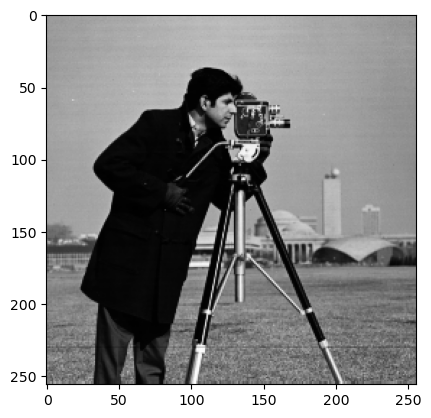

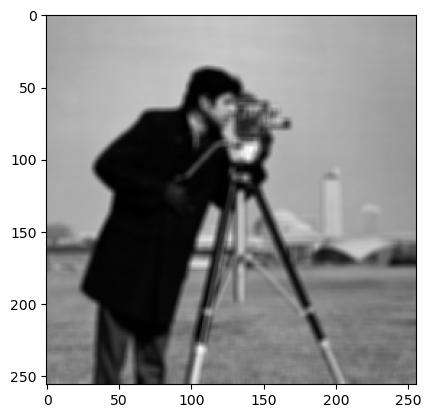

In [11]:
img = cv2.imread("camaraman.tif",0)

kernel = np.ones((5,5),np.float32)/(5*5)
dst_im = cv2.filter2D(img,-1,kernel)

plt.imshow(img,cmap='gray')
plt.show()
plt.imshow(dst_im,cmap='gray')
plt.show()

* Sobel operator

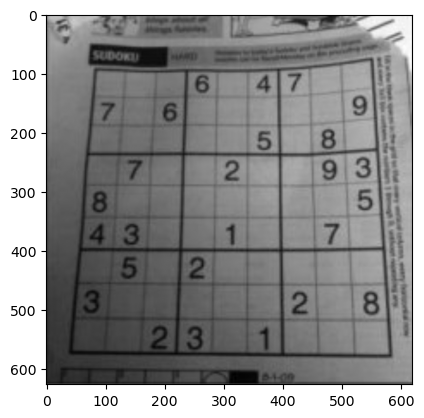

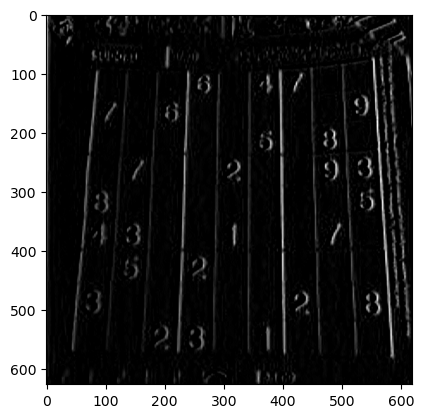

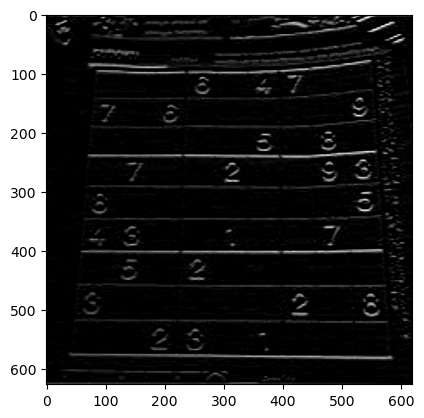

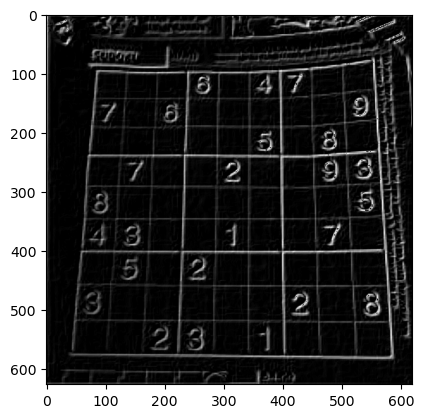

In [12]:
img = cv2.imread("sudoku.jpg",0)
sobelx = cv2.Sobel(img,cv2.CV_8U,1,0,ksize=3)
sobely = cv2.Sobel(img,cv2.CV_8U,0,1,ksize=3)
plt.imshow(img,cmap='gray')
plt.show()

plt.imshow(sobelx,cmap='gray')
plt.show()
plt.imshow(sobely,cmap='gray')
plt.show()

f = np.abs(sobelx) + np.abs(sobely)
plt.imshow(f,cmap = 'gray')
plt.show()



* Laplacian Filtering

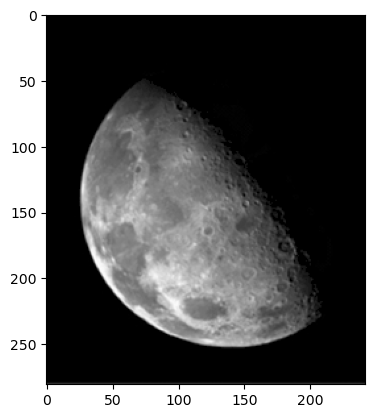

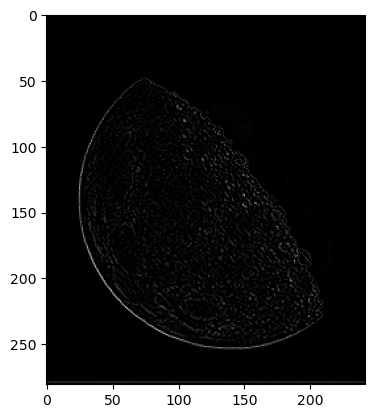

In [13]:
img_gray = cv2.imread("moon.png",0)

lap_filter = np.array([[0,1,0],[1,-4,1],[0,1,0]],np.int16)
dst_im = cv2.filter2D(img_gray,-1,lap_filter)

plt.imshow(img_gray,cmap='gray')
plt.show()
plt.imshow(dst_im,cmap='gray')
plt.show()

## Exercise #3 Enhancing the image
* Enhancing the moon using laplacian filter

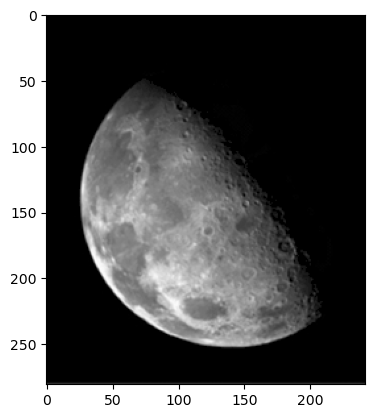

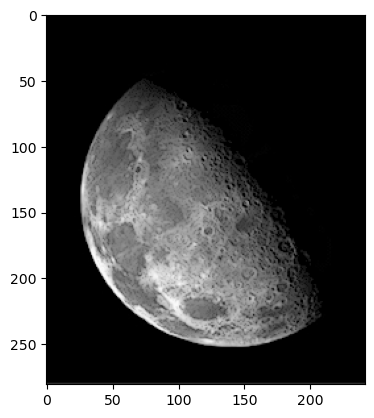

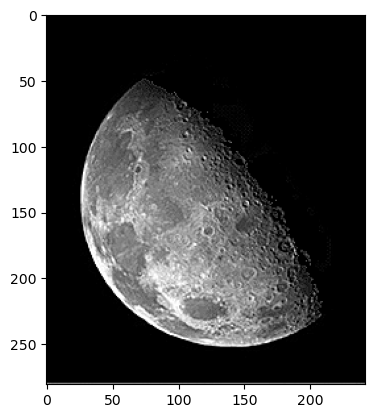

In [14]:
img_gray = cv2.imread("moon.png",0)

# TODO: Enhancing the moon using laplacian filter
lap_filter = np.array([[0,1,0],[1,-4,1],[0,1,0]],np.int16)
dst_im = cv2.filter2D(img_gray,-1,lap_filter)

plt.imshow(img_gray,cmap='gray')
plt.show()

sharpen_img = cv2.subtract(img_gray, dst_im)
plt.imshow(sharpen_img,cmap='gray')
plt.show()

# 2
sh_filter = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]],np.int16)
sharpen_img2 = cv2.filter2D(img_gray,-1,sh_filter)
plt.imshow(sharpen_img2,cmap='gray')
plt.show()
